In [4]:
import zipfile
with zipfile.ZipFile('/content/online+retail (3).zip','r')as zip_ref:
  zip_ref.extractall('/content/')

In [5]:
import pandas as pd
df =pd.read_excel('/content/Online Retail.xlsx')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[(df['Quantity']>0) &(df['UnitPrice']>0)]
df = df.drop_duplicates()
print(df.shape)

(392692, 8)


In [7]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [8]:
import datetime as dt
ref_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


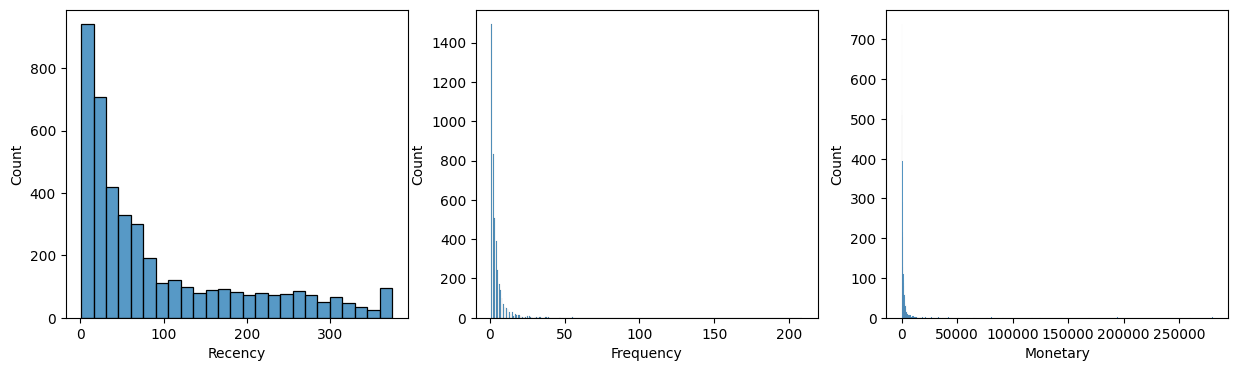

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(rfm['Recency'], ax=axes[0])
sns.histplot(rfm['Frequency'], ax=axes[1])
sns.histplot(rfm['Monetary'], ax=axes[2])
plt.show()

In [10]:
rfm = rfm[rfm['Monetary'] < rfm['Monetary'].quantile(0.99)]
rfm = rfm[rfm['Frequency'] < rfm['Frequency'].quantile(0.99)]
print(rfm.shape)

(4250, 3)


In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

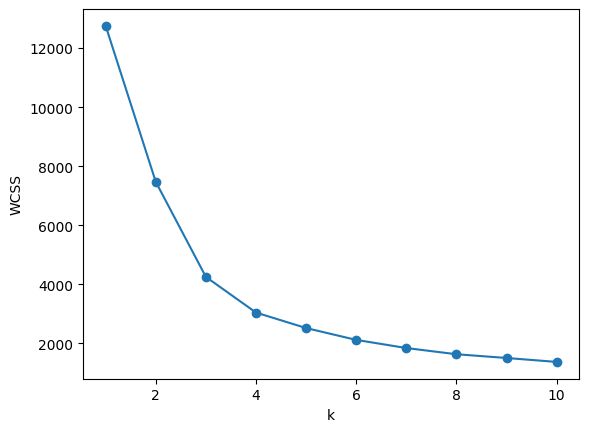

In [13]:
from sklearn.cluster import KMeans
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    wcss.append(km.inertia_)

import matplotlib.pyplot as plt
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('k')
plt.ylabel('WCSS')
plt.show()

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12347.0,2,7,4310.00,3
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,2
12352.0,36,8,2506.04,3


In [15]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,51.579208,2.246175,683.267297
1,19.534653,14.529703,7430.157574
2,252.543307,1.473425,429.196605
3,30.348148,7.055556,2637.396358


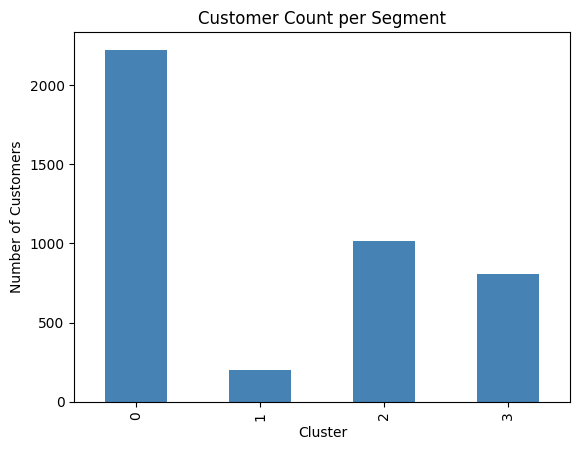

In [16]:
import matplotlib.pyplot as plt
rfm['Cluster'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Customer Count per Segment')
plt.show()

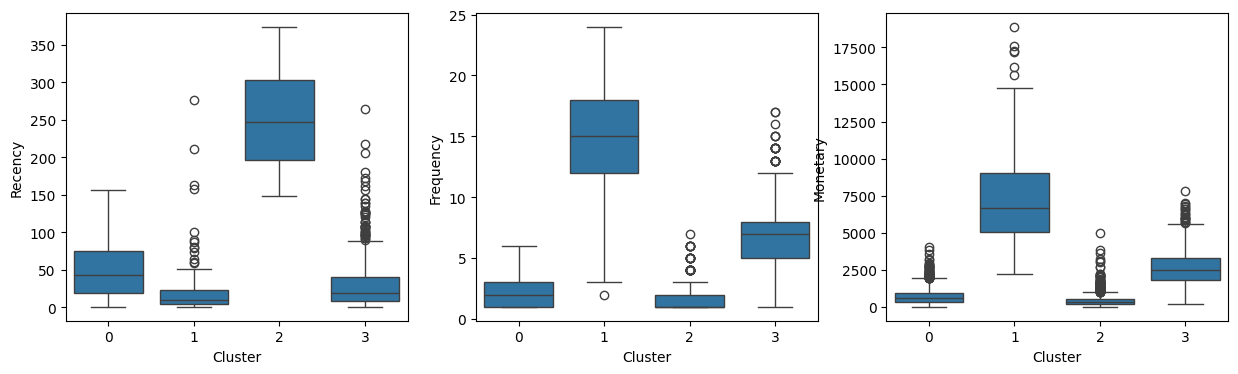

In [17]:
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.boxplot(x='Cluster', y='Recency', data=rfm, ax=axes[0])
sns.boxplot(x='Cluster', y='Frequency', data=rfm, ax=axes[1])
sns.boxplot(x='Cluster', y='Monetary', data=rfm, ax=axes[2])
plt.show()

## Segment Recommendations

**Cluster 1 – Champions** (low Recency, high Frequency, high Monetary)
Reward with loyalty perks, early access to new products, VIP treatment. These customers drive the most revenue — protect this relationship.

**Cluster 3 – Loyal Customers** (low Recency, moderate Frequency/Monetary)
Upsell and cross-sell opportunities. Encourage them toward Champion status with personalized offers.

**Cluster 0 – At Risk** (moderate Recency, low Frequency/Monetary)
Re-engagement campaigns — reminder emails, limited-time discounts to bring them back before they churn further.

**Cluster 2 – Hibernating / Lost** (high Recency, lowest Frequency/Monetary)
Win-back campaigns with strong incentives, or deprioritize marketing spend here if response rates are historically low.